# Testing SNEC dev
author: [Mathieu Renzo](mrenzo@arizona.edu)

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
from plot_aux import SNEC_output_parser
import astropy.units as u
from plot_v_r import plot_vel_radius_at_time_t

Hardcoded some constants


In [2]:
root = "/home/mrenzo/Documents/Research/codes/SNEC-1.01/Data/"
baseline = root+"baseline/"
testing_weak_expl = root+"testing_weak_expl/"
testing1 = root+"testing1/"
testing = root+"testing/"

/home/mrenzo/Documents/Research/codes/miniforge3/envs/dev_SNEC/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  func(*args, **kwargs)
/home/mrenzo/Documents/Research/codes/miniforge3/envs/dev_SNEC/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  fig.canvas.print_figure(bytes_io, **kw)


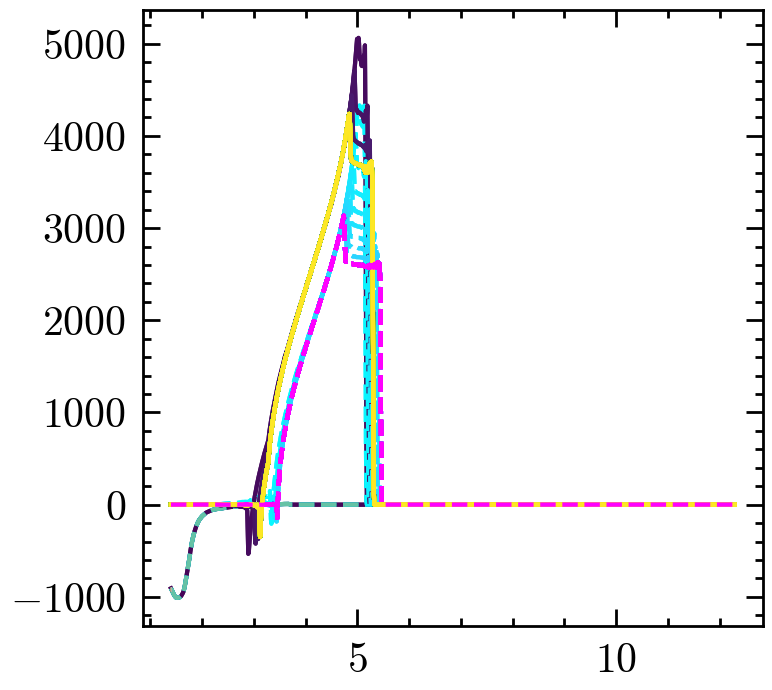

In [3]:
fig = plt.figure()
gs = gridspec.GridSpec(150, 100)
ax = fig.add_subplot(gs[:, :])

baseline_vel = baseline+"vel.xg"
testing_weak_expl_vel = testing_weak_expl+"vel.xg"
testing_vel = testing+"vel.xg"

times = np.linspace(0, 86400, 100)
colors1 = plt.cm.viridis(np.linspace(0,1, len(times)))
colors2 = plt.cm.cool(np.linspace(0,1, len(times)))
colors3 = plt.cm.Set2(np.linspace(0,1, len(times)))
for i, t in enumerate(times):
    plot_vel_radius_at_time_t(t, baseline_vel, ax=ax, ls='-', c=colors1[i])
    plot_vel_radius_at_time_t(t, testing_weak_expl_vel, ax=ax, ls='--', c=colors2[i])
    plot_vel_radius_at_time_t(t, testing_vel, ax=ax, ls='--', c=colors3[i])


In [4]:
def plot_mass_radius(t, mass_out, ax=None, **kwargs):
    data = SNEC_output_parser(mass_out)
    keys = np.array(list(data.keys()))
    times = keys * u.s
    try:
        units = times.unit
    except AttributeError:
        times *= u.s
    index_time_of_interest = np.argmin(np.absolute(times-t))
    key_of_interest = keys[index_time_of_interest]
    mass = data[key_of_interest][:, 1] * u.g
    radius = data[key_of_interest][:, 0] * u.cm
    if not ax:
        fig = plt.figure()
        gs = gridspec.GridSpec(150, 100)
        ax = fig.add_subplot(gs[:, :])
    ax.plot(radius.to(u.cm), mass.to(u.Msun), **kwargs)
    return mass, radius

Text(0, 0.5, '$m \\ [M_{\\odot}]$')

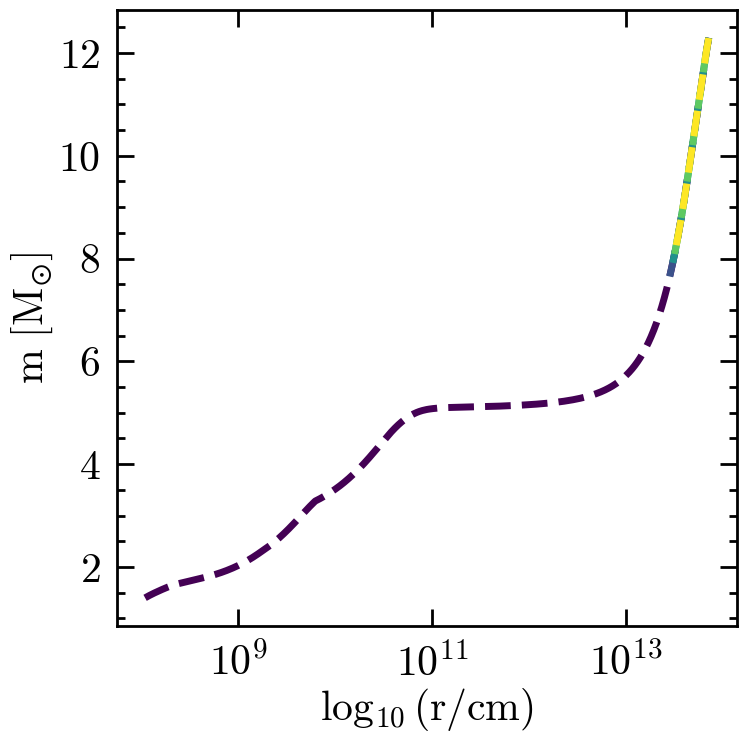

In [5]:
# mass vs time
fig = plt.figure()
gs = gridspec.GridSpec(150, 100)
ax = fig.add_subplot(gs[:, :])

baseline_mass = baseline+"mass.xg"
testing_weak_expl_mass = testing_weak_expl+"mass.xg"
testing_mass = testing+"mass.xg"

vel_data = SNEC_output_parser(baseline_vel)
keys = np.array(list(vel_data.keys()))
vel_times = keys * u.s
colors1 = plt.cm.viridis(np.linspace(0,1, len(vel_times)))

for i, t in enumerate(vel_times):
    # plot_mass_radius(t, baseline_mass, ls='-', c=colors1[i], ax=ax)
    # plot_mass_radius(t, testing_weak_expl_mass, ls='--', c=colors2[i], ax=ax)
    plot_mass_radius(t, testing_mass, ls='--', lw=5,  c=colors1[i], ax=ax)

ax.set_xscale("log")
ax.set_xlabel(r"$\log_{10}(r/\mathrm{cm})$")
ax.set_ylabel(r"$m \ [M_{\odot}]$")

In [6]:
# velocity as a function of radius at fixed time
def plot_v_radius_time(t, vel_out, mass_out, ax=None, annotate_inner_boundary=True, **kwargs):
    vel_data = SNEC_output_parser(vel_out)
    keys = np.array(list(vel_data.keys()))
    vel_times = keys * u.s
    try:
        units = t.unit
    except AttributeError:
        vel_times *= u.s
    mass_data = SNEC_output_parser(mass_out)
    keys = np.array(list(mass_data.keys()))
    mass_times = keys * u.s
    try:
        units = t.unit
    except AttributeError:
        t *= u.s
    # sanity check
    # print(vel_times == mass_times)
    index_time_of_interest = np.argmin(np.absolute(vel_times-t))
    key_of_interest = keys[index_time_of_interest]
    mass = mass_data[key_of_interest][:, 1] * u.g
    radius = mass_data[key_of_interest][:, 0] * u.cm
    vel = vel_data[key_of_interest][:, 1] * u.cm/u.s
    vel = vel.to(u.km/u.s)
    if not ax:
        fig = plt.figure()
        gs = gridspec.GridSpec(150, 100)
        ax = fig.add_subplot(gs[:, :])
    if annotate_inner_boundary:
        i_min_m = np.argmin(mass)
        ax.axvline(np.log10(radius[i_min_m].value), 0, 1, zorder=0, ls='--', lw=1, c='k')
    ax.plot(np.log10(radius.value), vel, **kwargs)
    # ax.scatter(np.log10(radius.value), vel, **kwargs)
    

# test
# plot_v_radius_time(t, baseline_vel, baseline_mass)

/tmp/ipykernel_1206006/547100905.py:31: RuntimeWarning: invalid value encountered in log10
  ax.axvline(np.log10(radius[i_min_m].value), 0, 1, zorder=0, ls='--', lw=1, c='k')
/tmp/ipykernel_1206006/547100905.py:32: RuntimeWarning: invalid value encountered in log10
  ax.plot(np.log10(radius.value), vel, **kwargs)


(-1050.0, 10.0)

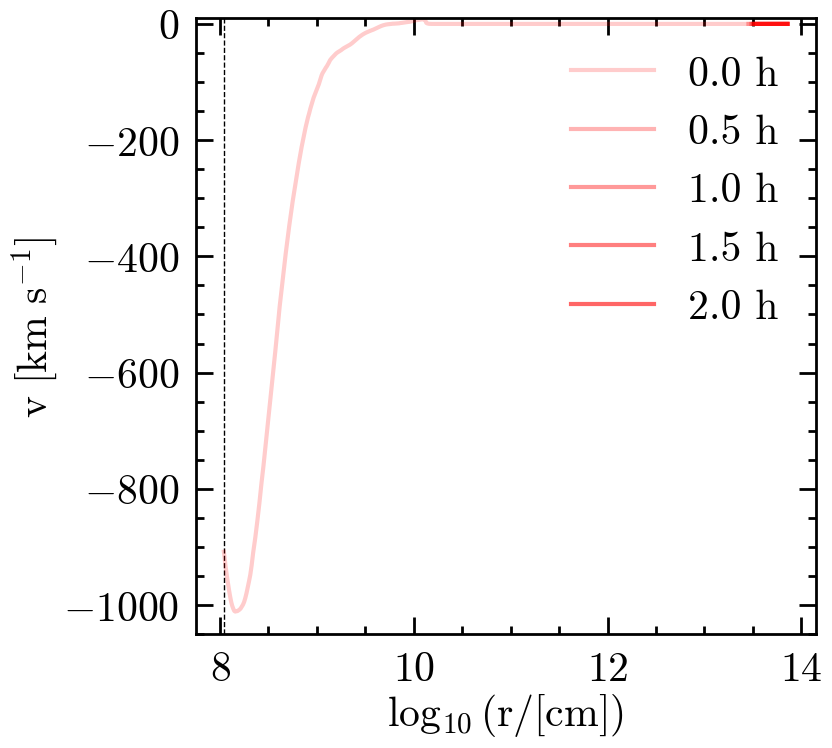

In [8]:
fig = plt.figure()
gs = gridspec.GridSpec(150, 100)
ax = fig.add_subplot(gs[:, :])

vel_data = SNEC_output_parser(baseline_vel)
keys = np.array(list(vel_data.keys()))
vel_times = keys * u.s

# times = np.linspace(0, 86400, 100)
# colors1 = plt.cm.viridis(np.linspace(0,1, len(times)))
for i, t in enumerate(vel_times):
    # if i%2 ==0: continue
    alpha = 1.0-(0.8 - 0.1*i)
    # plot_v_radius_time(t, baseline_vel, baseline_mass, ax=ax, label=f"{t.to(u.h):.1f}", c='b', alpha=alpha)
    # plot_v_radius_time(t, testing_weak_expl_vel, testing_weak_expl_mass, ax=ax, label=f"{t.to(u.h):.1f}", c='r', alpha=alpha)
    plot_v_radius_time(t, testing_vel, testing_mass, ax=ax, label=f"{t.to(u.h):.1f}", alpha=alpha, c='r')

ax.set_xlabel(r'$\log_{10}(r/\mathrm{[cm]})$')
ax.set_ylabel(r'$v \ [\mathrm{km\ s^{-1}}]$')
ax.legend()
ax.set_ylim(-1050, 10)

0
1
2


/tmp/ipykernel_1206006/1787484617.py:14: RuntimeWarning: divide by zero encountered in log10
  ax.plot(mass.to(u.Msun), np.log10(rho.value), **kwargs)


3
4


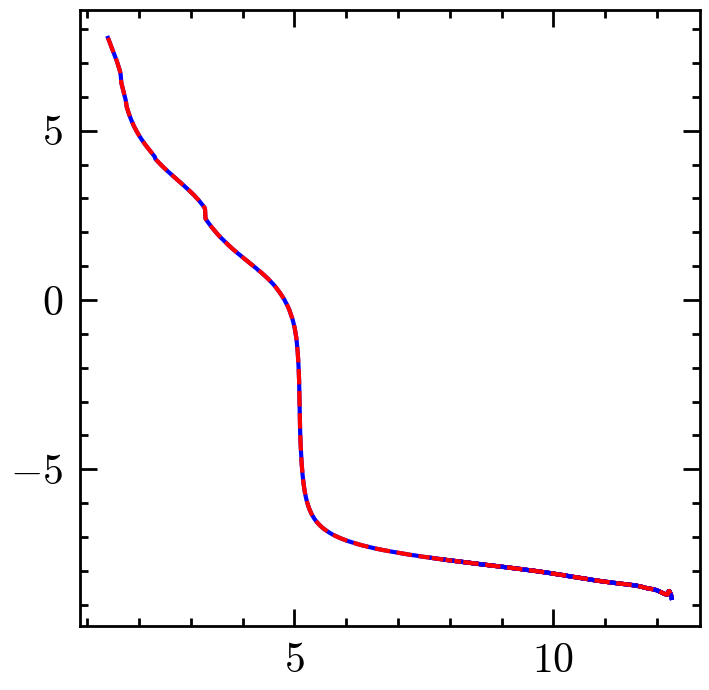

In [9]:
# density profiles?
def plot_rho_pfile(t, rho_out, ax=None, **kwargs):
    data = SNEC_output_parser(rho_out)
    keys = np.array(list(data.keys()))
    times = keys * u.s
    try:
        units = times.unit
    except AttributeError:
        times *= u.s
    index_time_of_interest = np.argmin(np.absolute(times-t))
    key_of_interest = keys[index_time_of_interest]
    rho = data[key_of_interest][:, 1] * u.g/u.cm**3
    mass = data[key_of_interest][:, 0] * u.g
    ax.plot(mass.to(u.Msun), np.log10(rho.value), **kwargs)



fig = plt.figure()
gs = gridspec.GridSpec(150, 100)
ax = fig.add_subplot(gs[:, :])

testing_rho = testing+"rho.xg"
testing_rho1 = testing1+"rho.xg"

for i, t in enumerate(vel_times):
    print(i)
    plot_rho_pfile(t, testing_rho, ax=ax, c='b')
    plot_rho_pfile(t, testing_rho1, ax=ax, ls='--', c='r')


In [13]:
# Mass vs time
mass_data = SNEC_output_parser(testing_mass)
keys = np.array(list(mass_data.keys()))
mass_times = keys * u.s
try:
    units = mass_times.unit
except AttributeError:
    mass_times *= u.s

for i, t in enumerate(mass_times):
    mass = mass_data[keys[i]][:, 1] * u.g
    print(t, min(mass).to(u.Msun), max(mass).to(u.Msun))

0.0 s 1.400359171935954 solMass 12.292135711144635 solMass
1890.1257732660456 s 1.400359171935954 solMass 12.292135711144635 solMass
3772.187326289619 s 1.400359171935954 solMass 12.292135711144635 solMass
5562.122104487856 s 1.400359171935954 solMass 12.292135711144635 solMass
7362.122104487856 s 1.400359171935954 solMass 12.292135711144635 solMass
9162.122104487855 s 1.400359171935954 solMass 12.292135711144635 solMass
10962.122104487855 s 1.400359171935954 solMass 12.292135711144635 solMass
12762.122104487855 s 1.400359171935954 solMass 12.292135711144635 solMass
14562.122104487855 s 1.400359171935954 solMass 12.292135711144635 solMass
16362.122104487855 s 1.400359171935954 solMass 12.292135711144635 solMass
18162.122104487855 s 1.400359171935954 solMass 12.292135711144635 solMass
19962.122104487855 s 1.400359171935954 solMass 12.292135711144635 solMass
21762.122104487855 s 1.400359171935954 solMass 12.292135711144635 solMass
23562.122104487855 s 1.400359171935954 solMass 12.2921357

61362.122104487855 s 1.400359171935954 solMass 12.292135711144635 solMass
63162.122104487855 s 1.400359171935954 solMass 12.292135711144635 solMass
64962.122104487855 s 1.400359171935954 solMass 12.292135711144635 solMass
66762.12210448785 s 1.400359171935954 solMass 12.292135711144635 solMass
68562.12210448785 s 1.400359171935954 solMass 12.292135711144635 solMass
70362.12210448785 s 1.400359171935954 solMass 12.292135711144635 solMass
72162.12210448785 s 1.400359171935954 solMass 12.292135711144635 solMass
73962.12210448785 s 1.400359171935954 solMass 12.292135711144635 solMass
75762.12210448785 s 1.400359171935954 solMass 12.292135711144635 solMass
77562.12210448785 s 1.400359171935954 solMass 12.292135711144635 solMass
79362.12210448785 s 1.400359171935954 solMass 12.292135711144635 solMass
81162.12210448785 s 1.400359171935954 solMass 12.292135711144635 solMass
82962.12210448785 s 1.400359171935954 solMass 12.292135711144635 solMass
84762.12210448785 s 1.400359171935954 solMass 12